# All computations

In [2]:
import numpy as np
import pandas as pd
import os

import sys
sys.path.append('..')

## Dataframe computations

In [2]:
from surface_functions import compute_surface_variance, compute_surface_roughness, compute_heightdifference_correlations
from surface_functions import compute_structure_factor, compute_phase_covariance
from fluctuation_functions import compute_rescaled_phases_at_index

### 2. Roughness

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [4]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "../Simulations_1D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (17499) to: Simulations/average_simulations.pkl


In [5]:
avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
Columnar_delta0_L125_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.11461032003170477, 0.1569503858630901,...","[0.0, 0.11770856603007997, 0.16237676956316305..."
Columnar_delta0_L250_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.12222002382088445, 0.17058895747819514...","[0.0, 0.123841119916426, 0.1734795250608667, 0..."
Columnar_delta0_L500_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.1258834998158019, 0.17711769638802907,...","[0.0, 0.1266989469781417, 0.17860927908329094,..."
Columnar_delta0_L1000_K40.0_T20000_M8362,Columnar,0.000000,0,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",8362,20000,"[0.0, 0.12770683115079906, 0.18033726902189454...","[0.0, 0.128123927460464, 0.1810916949712311, 0..."
Columnar_deltaatan5_L125_K40.0_T20000_M2999,Columnar,1.373401,atan5,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2999,20000,"[0.0, 0.18420179567662112, 0.25530045465918827...","[0.0, 0.18622031268713773, 0.25899181404794874..."
Columnar_deltaatan5_L250_K40.0_T20000_M3000,Columnar,1.373401,atan5,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.18873564913862148, 0.2637951097933861,...","[0.0, 0.18972890958847194, 0.2656174631525605,..."
Columnar_deltaatan5_L500_K40.0_T20000_M3000,Columnar,1.373401,atan5,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.19145951500897088, 0.26844303429675004...","[0.0, 0.19195445882449544, 0.26933612511008787..."
Columnar_deltaatan5_L1000_K40.0_T20000_M8000,Columnar,1.373401,atan5,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",8000,20000,"[0.0, 0.19257094555552245, 0.2704151796116424,...","[0.0, 0.1928261137365568, 0.27088733058570574,..."


### 3. Height-height correlations (takes the longest, ~40min)

In [6]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_heightdifference_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [7]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

### 4. Structure Factor

In [8]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [9]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

### 5. Phase covariance (takes long as well)

In [10]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        hprodh_average_list = []  # used to compute per-sim \overline{h(x,t)h(x+r,t)}
        h_average_list = []  # used to compute per-sim height \overline{h(x,t)}

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            hprodh_average, h_average = compute_phase_covariance(phases)

            hprodh_average_list.append(hprodh_average)
            h_average_list.append(h_average)

        # Avoid chained-assignment issues
        df = df.copy()
        df["hprodh_average"] = hprodh_average_list
        df["h_average"] = h_average_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            hprodh_average_arrays = [np.asarray(r, dtype=float) for r in group["hprodh_average"]]
            h_average_arrays = [np.asarray(r, dtype=float) for r in group["h_average"]]

            # Term 1: < overline{φ(x, t) φ(x + r, t)} >
            term1 = np.mean(np.stack(hprodh_average_arrays, axis=0), axis=0)

            # Term 2: ( < overline{φ}(x, t) > )^2
            # Note: h_average_arrays has shape (M, Nt), so we mean over axis 0 to get (Nt,)
            term2 = np.mean(np.stack(h_average_arrays, axis=0), axis=0)**2

            # We need to broadcast term2 (Nt,) to match term1 (Nt, N)
            # Since term2 varies only with time, we subtract it from every 'r' column
            mean_phasecovariance = term1 - term2[:, np.newaxis]

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [11]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

### 6. Phase fluctuations

Computing the phase fluctuations properly requires knowing beta, and the saturation time to remain in the growth regime.

In [5]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

# Adjustment to the saturation time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

In [6]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        beta = beta_dict[typenoise][delta_to_label[deltaname]]
        z = z_dict[typenoise][delta_to_label[deltaname]]

        ## AVERAGE FLUCTUATION STATISTICS PER (K, L, T) ##
        # group by K, L, T and compute fluctuation statistics for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            
            # if K_val not in Ks or T_val != T or L_val != L:
            #     continue
            
            t_cross = tx[typenoise][delta_to_label[deltaname]] * (L_val ** z)
            
            per_seed_varphis = []
            for _, row in group.iterrows():
                t = np.asarray(row["t"])
                phases = np.asarray(row["phases"])

                t0_idx = int(np.argmin(np.abs(t - 50)))-2 # optional, where to start.

                for ti_idx in range(t0_idx + 1, len(t)):
                    if t[ti_idx] < t_cross:
                        v = compute_rescaled_phases_at_index(phases, t, t0_idx, ti_idx, beta=beta)
                        per_seed_varphis.append(v)

            varphis_full = np.ravel(per_seed_varphis)
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "varphis_full": varphis_full,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [7]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "varphis_full"] = new_avg["varphis_full"]

avg_df.to_pickle(avg_df_path)

## Inspection of the computed quantities

In [3]:
# Scaling exponents
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ", "atan10": "KPZ"}

# Markers for different system sizes
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

# Vertical lines' colors for different system sizes (roughness evolution plot)
vlinecolordict = {125: "tab:blue", 250: "tab:green", 500: "tab:orange", 1000: "tab:red"}


In [4]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [5]:
df_TimeDep = avg_df[(avg_df["K"] == 1) & (avg_df["T"] == 20000)]
df_Columnar = avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

print("TimeDep", df_TimeDep[["deltaname", "L", "M"]])
print()
print("Columnar", df_Columnar[["deltaname", "L", "M"]])

TimeDep                                            deltaname     L     M
avg_id                                                          
TimeDep_delta0_L125_K1.0_T20000_M3000              0   125  3000
TimeDep_delta0_L250_K1.0_T20000_M3000              0   250  3000
TimeDep_delta0_L500_K1.0_T20000_M3000              0   500  3000
TimeDep_delta0_L1000_K1.0_T20000_M5991             0  1000  5991
TimeDep_deltaatan5_L125_K1.0_T20000_M3000      atan5   125  3000
TimeDep_deltaatan5_L250_K1.0_T20000_M3000      atan5   250  3000
TimeDep_deltaatan5_L500_K1.0_T20000_M2927      atan5   500  2927
TimeDep_deltaatan5_L1000_K1.0_T20000_M5637     atan5  1000  5637

Columnar                                              deltaname     L     M
avg_id                                                            
Columnar_delta0_L125_K40.0_T20000_M3000              0   125  3000
Columnar_delta0_L250_K40.0_T20000_M3000              0   250  3000
Columnar_delta0_L500_K40.0_T20000_M3000              0   500  30

## Plotting results

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from scipy.integrate import quad
import scienceplots

plt.style.use(["science","no-latex"])

from plotting_helpers_evolution import plot_roughness_evolution, plot_heightdifference_evolution, plot_structurefactor_evolution, plot_phasecovariance_evolution
from plotting_helpers_collapse import plot_roughness_collapse, plot_heightdifference_collapse, plot_structurefactor_collapse, plot_phasecovariance_collapse
from fluctuation_functions import plot_fluctuations_pdf

In [7]:
T = 20000
L = 1000

In [8]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

In [9]:
# Markers for different system sizes
markerdict = {0: "x", 1: "o"}
markerrdict = {0: "x", 5: "o"}
colordict = {125: "tab:red", 250: "tab:blue", 500: "tab:green", 1000: "tab:orange"}

delta_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        color="black",
        linestyle="None",
        markersize=8,
        label=fr"$\tan\delta={tandelta}$"
    )
    for tandelta, marker in markerrdict.items()
]

L_handles = [
    Line2D(
        [0], [0],
        color=color,
        linestyle="-",
        linewidth=2,
        label=fr"$L={L}$"
    )
    for L, color in colordict.items()
]

# Vertical lines' colors for different system sizes (roughness evolution plot)
vlinecolordict = {125: "tab:blue", 250: "tab:green", 500: "tab:orange", 1000: "tab:red"}

### 2. Roughness

# TimeDep
## 0
	 $t_\star$(125) = 156.25.
	 $t_\star$(250) = 625.0.
	 $t_\star$(500) = 2500.0.
	 $t_\star$(1000) = 10000.0.
## atan5
	 $t_\star$(125) = 139.75424859373686.
	 $t_\star$(250) = 395.28470752104744.
	 $t_\star$(500) = 1118.033988749895.
	 $t_\star$(1000) = 3162.2776601683795.
# Columnar
## 0
	 $t_\star$(125) = 10.416666666666666.
	 $t_\star$(250) = 41.666666666666664.
	 $t_\star$(500) = 166.66666666666666.
	 $t_\star$(1000) = 666.6666666666666.
## atan5
	 $t_\star$(125) = 8.886027044968978.
	 $t_\star$(250) = 22.80911447191511.
	 $t_\star$(500) = 58.54761642746535.
	 $t_\star$(1000) = 150.2830543271767.


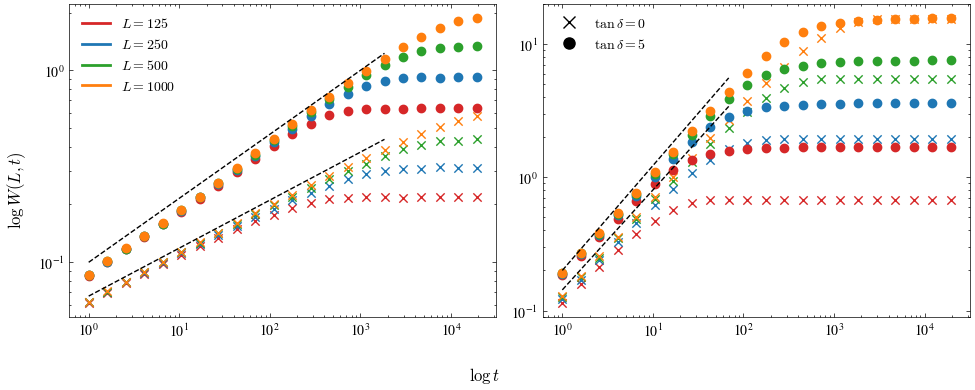

In [10]:
def plot_roughness_evolution(avg_df, T, tx, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1,2, figsize=(10,4))
    
    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\log W(L,t)$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):
        print("#", typenoise)
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            print("##", deltaname)
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_roughness = row["mean_roughness"]
                L = row["L"]
                K = row["K"]
                
                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])
                
                print("\t", fr"$t_\star$({L}) = {t_cross}.")

                ax[i].scatter(t, mean_roughness, label=r"$L=$" + str(L), c=colordict[L], marker=markerdict[j])

            ax[i].set_xscale('log')
            ax[i].set_yscale('log')

    # Scalings
    ax[0].loglog(t[1:-5:], t[1:-5:]**(beta_dict["TimeDep"]["EW"]) /15, linestyle="--", color="k")#, label=r"$\beta_{EW}=1/4$", linestyle="--", color="k")
    ax[0].loglog(t[1:-5:], t[1:-5:]**(beta_dict["TimeDep"]["KPZ"]) /10, linestyle="--", color="k")#, label=r"$\beta_{KPZ}=1/3$", linestyle="--", color="k")

    ax[1].loglog(t[1:-12:], t[1:-12:]**(beta_dict["Columnar"]["EW"]) / 7, linestyle="--", color="k")#, label=r"$\beta_{EW}=3/4$")
    ax[1].loglog(t[1:-12:], t[1:-12:]**(beta_dict["Columnar"]["KPZ"]) / 5, linestyle="--", color="k")#, label=r"$\beta_{KPZ}\approx 0.7867$")

    ax[0].legend(
        handles=L_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )
    
    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/roughness_evolution.png", dpi=300)
    plt.show()

plot_roughness_evolution(avg_df, T, tx, save=True)

#### Estimation of alphas from plateaus

In [11]:
def lastW_computation(avg_df, T, Ks=[1,40]):

    lastW_EW = {"TimeDep":[], "Columnar":[]}
    lastW_KPZ = {"TimeDep":[], "Columnar":[]}
    
    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_roughness = row["mean_roughness"]
                L = row["L"]
                K = row["K"]

                if deltaname == "0":
                    lastW_EW[typenoise].append(mean_roughness[-1])
                if deltaname == "atan5":
                    lastW_KPZ[typenoise].append(mean_roughness[-1])
        
    return lastW_EW, lastW_KPZ 

lastW_EW, lastW_KPZ = lastW_computation(avg_df, T, Ks=[1,40])

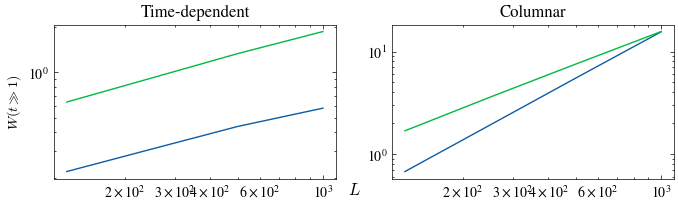

In [12]:
fig, ax = plt.subplots(1,2, figsize=(8,2), sharex=True)
ax[0].set_title("Time-dependent")
ax[1].set_title("Columnar")
ax[0].plot([125,250,500,1000], lastW_EW["TimeDep"])
ax[1].plot([125,250,500,1000], lastW_EW["Columnar"])
ax[0].plot([125,250,500,1000], lastW_KPZ["TimeDep"])
ax[1].plot([125,250,500,1000], lastW_KPZ["Columnar"])
ax[0].set_ylabel(r"$W(t\gg1)$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
fig.supxlabel("$L$")
# plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import linregress

# Your X data
x_data = [125, 250, 500, 1000]

# Dictionary to store the results
results = {}

# Combine your data into a structure we can loop through
datasets = {
    "EW_TimeDep": lastW_EW["TimeDep"],
    "KPZ_TimeDep": lastW_KPZ["TimeDep"],
    "EW_Columnar": lastW_EW["Columnar"],
    "KPZ_Columnar": lastW_KPZ["Columnar"]
}

# Compute linear regression for each dataset
for label, y_data in datasets.items():
    # linregress expects array-like inputs
    slope, intercept, r_value, p_value, std_err = linregress(np.log(x_data), np.log(y_data))
    
    results[label] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2
    }
    
    print(f"{label}:")
    print(f"  Estimated Slope: {slope:.6f}")
    print(f"  R-squared:       {r_value**2:.4f}\n")

EW_TimeDep:
  Estimated Slope: 0.469305
  R-squared:       0.9976

KPZ_TimeDep:
  Estimated Slope: 0.520359
  R-squared:       0.9995

EW_Columnar:
  Estimated Slope: 1.506895
  R-squared:       1.0000

KPZ_Columnar:
  Estimated Slope: 1.069695
  R-squared:       0.9999



In [20]:
alpha_dict

{'TimeDep': {'EW': 0.5, 'KPZ': 0.5}, 'Columnar': {'EW': 1.5, 'KPZ': 1.07}}

#### Estimation of betas from slopes

#### Family-Vicsek collapse

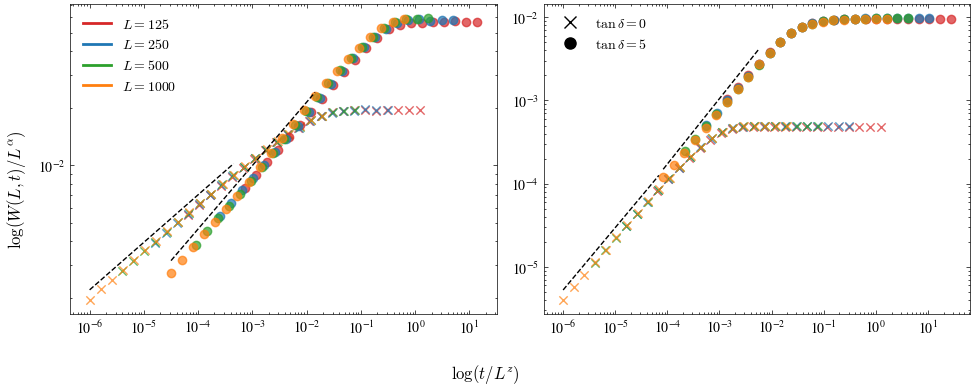

In [21]:
def plot_roughness_collapse(avg_df, T, tx, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Roughness collapse under different noise types")

    fig.supxlabel(r"$\log (t/L^z)$")
    fig.supylabel(r"$\log (W(L,t) / L^\alpha)$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
                # & (avg_df["L"] < 1000)
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]
                mean_roughness = row["mean_roughness"]
                L = row["L"]
                K = row["K"]

                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

                # Collapse variables
                tLz = t / L**z
                WLa = mean_roughness / L**alpha
                
                ax[i].scatter(tLz, WLa, label=r"$L=$" + str(L), c=colordict[L], marker=markerdict[j], alpha=0.7)

            ax[i].set_xscale('log')
            ax[i].set_yscale('log')

    # Scalings
    ax[0].loglog(t[1:-8:] / L**(z_dict["TimeDep"]["EW"]), (t[1:-8:] / L ** (alpha_dict["TimeDep"]["EW"])) **(beta_dict["TimeDep"]["EW"]) /190,
                label=r"$\beta_{EW}=1/4$", linestyle="--", color="k")
    ax[0].loglog(t[1:-8:] / L**(z_dict["TimeDep"]["KPZ"]), (t[1:-8:] / L ** (alpha_dict["TimeDep"]["KPZ"])) **(beta_dict["TimeDep"]["KPZ"]) /100,
                label=r"$\beta_{KPZ}=1/3$", linestyle="--", color="k")

    ax[1].loglog(t[1:-12:] / L**(z_dict["Columnar"]["EW"]), (t[1:-12:] / L ** (alpha_dict["Columnar"]["EW"])) **(beta_dict["Columnar"]["EW"]) /80,
                label=r"$\beta_{EW}=3/4$", linestyle="--", color="k")
    ax[1].loglog(t[1:-12:] / L**(z_dict["Columnar"]["KPZ"]), (t[1:-12:] / L ** (alpha_dict["Columnar"]["KPZ"])) **(beta_dict["Columnar"]["KPZ"]) /20,
                label=r"$\beta_{KPZ}\approx 0.7867$", linestyle="--", color="k")

    ax[0].legend(
        handles=L_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )

    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/roughness_collapse.png", dpi=300)
    plt.show()

    return t
    
t = plot_roughness_collapse(avg_df, T, tx, save=True)

### 3. Height-difference correlations

In [22]:
t

array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
       4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
       2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
       1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
       1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
       7.55578378e+03, 1.20892560e+04, 1.93428197e+04])

In [23]:
timecolordict = {
    3: "tab:blue",
    6: "tab:orange",
    9: "tab:green",
    12: "tab:red",
    15: "tab:purple",
    18: "tab:brown",
}

time_handles = [
    Line2D(
        [0], [0],
        color=color,
        linestyle="-",
        linewidth=2,
        label=fr"$t\approx{int(t[ti])}$"
    )
    for ti, color in timecolordict.items()
]


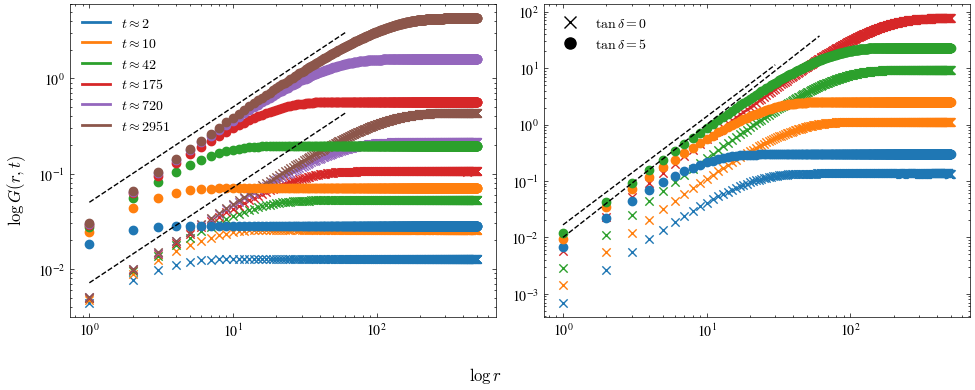

In [24]:
def plot_heightdifference_evolution(avg_df, L, T, tx, Ks=[1,40], t_intervals=3, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Height-difference correlation evolution under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log r$")
    fig.supylabel(r"$\log G(r,t)$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]            
                mean_heightheight = row["mean_heightheight"]
                L = row["L"]
                K = row["K"]
                
                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))
                        ax[i].scatter(rrange[:rlen//2], mean_heightheight[ti,:rlen//2], label=f"$t=${np.round(t[ti],2)}",
                                      c=timecolordict[ti], marker=markerdict[j])

            ax[i].set_xscale('log')
            ax[i].set_yscale('log')

    # scaling as r^(2\alpha) = r^1 for alpha = 1/2 (EW/KPZ)
    ax[0].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["EW"])/140, label=r"$\alpha_{EW}=1/2$", linestyle="--", color="k")
    ax[0].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["KPZ"])/20, label=r"$\alpha_{KPZ}=1/2$", linestyle="--", color="k")

    # scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
    ax[1].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["Columnar"]["EW"])/100, label=r"$\alpha_{loc}^{EW}=1$", linestyle="--", color="k")
    ax[1].loglog(rrange[1:int(rlen/32)], rrange[1:int(rlen/32)]**(2*alpha_loc_dict["Columnar"]["KPZ"])/60, label=r"$\alpha_{loc}^{KPZ}=0.96$", linestyle="--", color="k")

    
    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )
    
    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/heighdifference_evolution_{L}.png", dpi=300)
    plt.show()

plot_heightdifference_evolution(avg_df, L, T, tx, save=True)

#### Family-Vicsek collapse

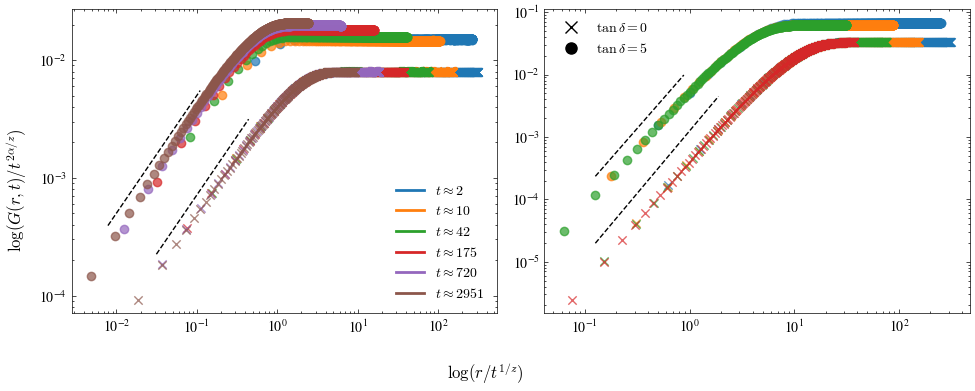

In [25]:
def plot_heightdifference_collapse(avg_df, L, T, tx, Ks=[1,40], t_intervals=3, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Height-difference correlation collapse under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log (r/ t^{1/z})$")
    fig.supylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]
                mean_heightheight = row["mean_heightheight"]
                L = row["L"]
                K = row["K"]

                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**z
                
                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))

                        # Collapse variables
                        rt1z = rrange[:rlen//2] / t[ti]**(1/z)
                        Gt2az = mean_heightheight[ti,:rlen//2] / t[ti]**(2*alpha/z)

                        ax[i].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}",
                                      c=timecolordict[ti], marker=markerdict[j], alpha=0.7)
                    
                ax[i].set_yscale('log')
                ax[i].set_xscale('log')
                
    # scaling as r^(2\alpha) = r^1 for alpha = 1/2 (EW/KPZ)
    ax[0].loglog(rt1z[1:int(rlen/64)]/2, (rt1z[1:int(rlen/64)]/2)**(2*alpha_loc_dict["TimeDep"]["EW"]) /140, label=r"$\alpha_{EW}=1/2$", linestyle="--", color="k")
    ax[0].loglog(rt1z[1:int(rlen/64)]/8, (rt1z[1:int(rlen/64)]/8)**(2*alpha_loc_dict["TimeDep"]["KPZ"])/20, label=r"$\alpha_{KPZ}=1/2$", linestyle="--", color="k")

    # scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
    ax[1].loglog(rt1z[2:int(rlen/32)], rt1z[2:int(rlen/32)]**(2*alpha_loc_dict["Columnar"]["EW"])/800, label=r"$\alpha_{loc}^{EW}=1$", linestyle="--", color="k")
    ax[1].loglog(rt1z[2:int(rlen/64)], rt1z[2:int(rlen/64)]**(2*alpha_loc_dict["Columnar"]["KPZ"])/80, label=r"$\alpha_{loc}^{KPZ}=0.96$", linestyle="--", color="k")

    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )
    
    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/heighdifference_collapse_{L}.png", dpi=300)
    plt.show()

plot_heightdifference_collapse(avg_df, L, T, tx, save=True)

theoretical: 1.5 0.5
better collapse: 1.5 0.54


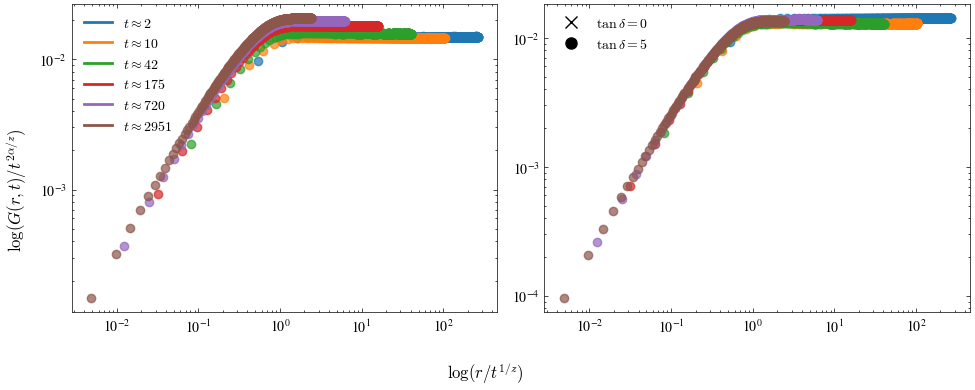

In [39]:
def plot_heightdifference_collapse_comparison(avg_df, L, T, tx, alpha_num=0.5, z_num=1.5, Ks=[1,40], t_intervals=3, save=False):
    
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Height-difference correlation collapse under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log (r/ t^{1/z})$")
    fig.supylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):
        if i == 1:
            continue
        
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            if j == 0:
                continue
                
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]
                mean_heightheight = row["mean_heightheight"]
                L = row["L"]
                K = row["K"]

                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

                # 1.5, 0.5
                print("theoretical:", z, alpha)
                print("better collapse:", z_num, alpha_num)
                
                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**z
                
                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))

                        # Collapse variables: theoretical
                        rt1z = rrange[:rlen//2] / t[ti]**(1/z)
                        Gt2az = mean_heightheight[ti,:rlen//2] / t[ti]**(2*alpha/z)

                        ax[0].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}",
                                      c=timecolordict[ti], marker=markerdict[j], alpha=0.7)

                        # Collapse variables: theoretical
                        rt1z_num = rrange[:rlen//2] / t[ti]**(1/z_num)
                        Gt2az_num = mean_heightheight[ti,:rlen//2] / t[ti]**(2*alpha_num/z_num)
                        
                        ax[1].scatter(rt1z_num, Gt2az_num, label=f"$t=${np.round(t[ti],2)}",
                                      c=timecolordict[ti], marker=markerdict[j], alpha=0.7)
                    
                ax[0].set_yscale('log')
                ax[0].set_xscale('log')
                ax[1].set_yscale('log')
                ax[1].set_xscale('log')
                
    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )
    
    plt.tight_layout()
    plt.show()

plot_heightdifference_collapse_comparison(avg_df, L, T, tx, alpha_num=0.54, z_num=1.5, save=True)

### 4. Structure factor

In [18]:

def analytical_Larkin_structurefactor(k, t, sigma, nu, d=1):
    """
    Analytical structure factor for the Larkin model (linear theory),
    equation (28) in the 2023 paper.
    """

    S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2

    return S_phi


/tmp/ipykernel_2359369/4081880528.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(0,1e3)
/tmp/ipykernel_2359369/4081880528.py:56: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(0,1e4)
/tmp/ipykernel_2359369/470982719.py:7: RuntimeWarning: divide by zero encountered in divide
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2
/tmp/ipykernel_2359369/470982719.py:7: RuntimeWarning: invalid value encountered in multiply
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2


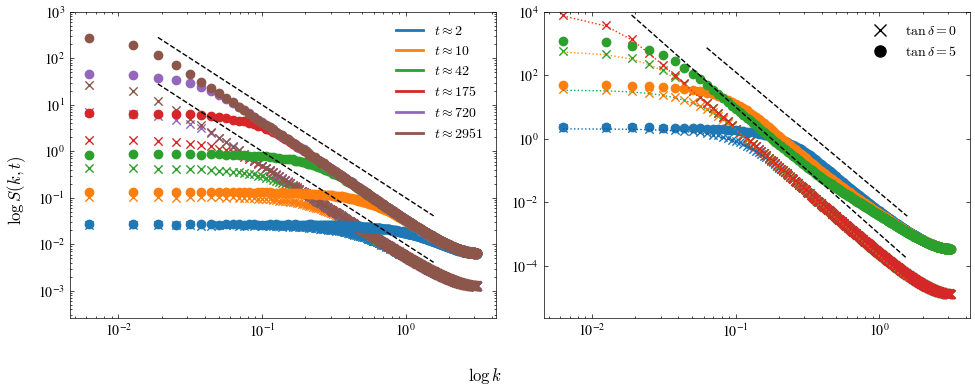

In [19]:

def plot_structurefactor_evolution(avg_df, L, T, tx, Ks=[1,40], t_intervals=3, analytical=False, sigma=1, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Structure factor under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log k$")
    fig.supylabel(r"$\log S(k,t)$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]            
                mean_structurefactor = row["mean_structurefactor"]
                L = row["L"]
                K = row["K"]

                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        klen = mean_structurefactor.shape[1]
                        krange = 2*np.pi*np.fft.fftfreq(klen)
                        
                        # we only plot up to half due to nyquist
                        ax[i].scatter(krange[:int(klen/2)], mean_structurefactor[ti,:int(klen/2)],
                                        label=f"$t=${np.round(t[ti],2)}", c=timecolordict[ti], marker=markerdict[j])
                    
                ax[i].set_yscale('log')
                ax[i].set_xscale('log')
                

    # scaling as k^(-2*alpha-1) = k^2 for alpha = 1/2 (EW/KPZ)
    ax[0].loglog(krange[3:int(klen/4)], krange[3:int(klen/4)]**(-2*alpha_s_dict["TimeDep"]["EW"]-1) / 100, label=r"$\alpha_s^{EW}=1/2$", linestyle="--", color="k")
    ax[0].loglog(krange[3:int(klen/4)], krange[3:int(klen/4)]**(-2*alpha_s_dict["TimeDep"]["KPZ"]-1) / 10, label=r"$\alpha_s^{KPZ}=1/2$", linestyle="--", color="k")

    # # scaling as k^(-2*alpha_s-1) for alpha_s approx 3/2 (EW) or 1.4 (KPZ)
    ax[1].loglog(krange[3:int(klen/4)], krange[3:int(klen/4)]**(-2*alpha_s_dict["Columnar"]["EW"]-1) / 1000, label=r"$\alpha_s^{EW}=3/2$", linestyle="--", color="k")
    ax[1].loglog(krange[10:int(klen/4)], krange[10:int(klen/4)]**(-2*alpha_s_dict["Columnar"]["KPZ"]-1) / 50, label=r"$\alpha_s^{KPZ}=1.4$", linestyle="--", color="k")

    ax[0].set_ylim(0,1e3)
    ax[1].set_ylim(0,1e4)

    # ax[0,0].text(0.5, 0.6, r"$k^{-2\alpha_s+1}$", fontsize=12, transform=ax[0,0].transAxes)
    # ax[1,0].text(0.5, 0.65, r"$k^{-2\alpha_s+1}$", fontsize=12, transform=ax[1,0].transAxes)
    # ax[0,1].text(0.5, 0.6, r"$k^{-2\alpha_s+1}$", fontsize=12, transform=ax[0,1].transAxes)
    # ax[1,1].text(0.6, 0.6, r"$k^{-2\alpha_s+1}$", fontsize=12, transform=ax[1,1].transAxes)

    handles, labels = ax[1].get_legend_handles_labels()

    # Add analytical Larkin structure factor for comparison to Columnar EW  case
    if analytical == True:
        for ti in range(len(t))[::t_intervals]:
            t_cross = tx["Columnar"]["EW"] * L**(z_dict["Columnar"]["EW"])
            if t[ti] > 0 and t[ti] < t_cross:
                Sphi = analytical_Larkin_structurefactor(krange, t[ti], sigma=sigma, nu=Ks[1], d=1)
                ax[1].loglog(krange[1:int(klen/4)], Sphi[1:int(klen/4)], linestyle=":")#, label=f"Anaytical (Larkin) $t={np.round(t[ti],1)}$")
                        
        handles.append(Line2D([0], [0], color='black', linestyle=':'))
        labels.append('Analytical (Larkin)')

    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )

    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/structurefactor_evolution_{L}.png", dpi=300)
    plt.show()

plot_structurefactor_evolution(avg_df, L, T, tx, analytical=True, sigma=1/40, save=True)

#### Family-Vicsek collapse

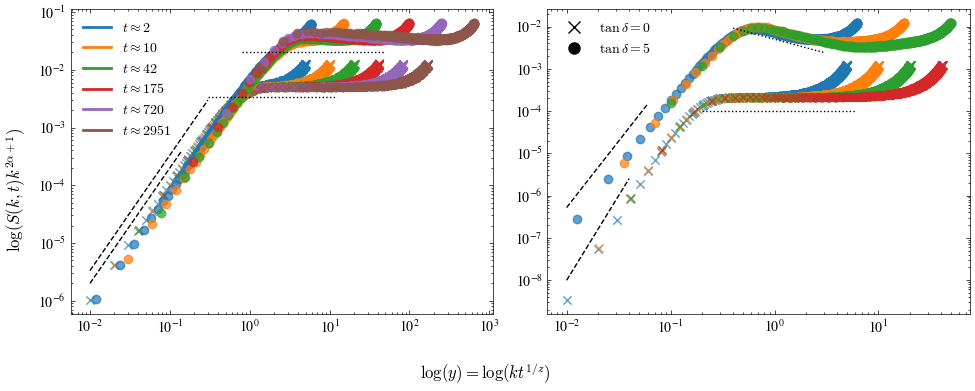

In [20]:

def plot_structurefactor_collapse(avg_df, L, T, tx, Ks=[1,40], t_intervals=3, save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Structure factor collapse under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$\log(y)=\log (k t^{1/z})$")
    fig.supylabel(r"$\log (S(k,t) k^{2\alpha+1})$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]            
                mean_structurefactor = row["mean_structurefactor"]
                L = row["L"]
                K = row["K"]

                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]

                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        klen = mean_structurefactor.shape[1] # we only plot up to half due to nyquist
                        krange = 2*np.pi*np.fft.fftfreq(klen)

                        # Collapse variables
                        kt1z = krange[:int(klen/2)] * t[ti]**(1/z)
                        Sk2a = mean_structurefactor[ti,:int(klen/2)] * krange[:int(klen/2)]**(2*alpha+1)

                        ax[i].scatter(kt1z, Sk2a, label=f"$t=${np.round(t[ti],2)}",
                                        c=timecolordict[ti], marker=markerdict[j], alpha=0.7)

                ax[i].set_yscale('log')
                ax[i].set_xscale('log')
                
    # initial scaling as y^(2*alpha+1) = k^2 for alpha = 1/2 (EW/KPZ)
    kt1z_init = kt1z/10
    ax[0].loglog(kt1z_init[1:int(klen/64)], kt1z_init[1:int(klen/64)]**(2*alpha_dict["TimeDep"]["EW"]+1) / 50, label=r"$\alpha^{EW}=1/2$", linestyle="--", color="k")
    ax[0].loglog(kt1z_init[1:int(klen/32)], kt1z_init[1:int(klen/32)]**(2*alpha_dict["TimeDep"]["KPZ"]+1) / 30, label=r"$\alpha^{KPZ}=1/2$", linestyle="--", color="k")

    # initial scaling as y^(2*alpha+1) for alpha approx 3/2 (EW) or 1.07 (KPZ)
    ax[1].loglog(kt1z_init[1:int(klen/200)], kt1z_init[1:int(klen/200)]**(2*alpha_dict["Columnar"]["EW"]+1) / 1, label=r"$\alpha^{EW}=3/2$", linestyle="--", color="k")
    ax[1].loglog(kt1z_init[1:int(klen/128)], kt1z_init[1:int(klen/128)]**(2*alpha_dict["Columnar"]["KPZ"]+1) / 1, label=r"$\alpha^{KPZ}=1.07$", linestyle="--", color="k")

    # intermediate scaling as y^(2*(alpha-alpha_s)) = k^2 for alpha = 1/2 (EW/KPZ)
    ax[0].loglog(kt1z[3:int(klen/8)], kt1z[3:int(klen/8)]**(2*alpha_dict["TimeDep"]["EW"]-2*alpha_s_dict["TimeDep"]["EW"]) / 300, label=r"$\alpha_s^{EW}=1/2$", linestyle=":", color="k")
    ax[0].loglog(kt1z[8:int(klen/2)], kt1z[8:int(klen/2)]**(2*alpha_dict["TimeDep"]["KPZ"]-2*alpha_s_dict["TimeDep"]["KPZ"]) / 50, label=r"$\alpha_s^{KPZ}=1/2$", linestyle=":", color="k")

    # intermediate scaling as y^(2*(alpha-alpha_s)) for alpha_s approx 3/2 (EW) or 1.4 (KPZ)
    ax[1].loglog(kt1z[2:int(klen/16)], kt1z[2:int(klen/16)]**(2*alpha_dict["Columnar"]["EW"]-2*alpha_s_dict["Columnar"]["EW"]) / 10000, label=r"$\alpha_s^{EW}=3/2$", linestyle=":", color="k")
    ax[1].loglog(kt1z[4:int(klen/32)], kt1z[4:int(klen/32)]**(2*alpha_dict["Columnar"]["KPZ"]-2*alpha_s_dict["Columnar"]["KPZ"]) / 200, label=r"$\alpha_s^{KPZ}=1.4$", linestyle=":", color="k")

    # ax[0,0].text(0.1, 0.6, r"$y^{2\alpha_s+1}$", fontsize=12, transform=ax[0,0].transAxes)
    # ax[0,1].text(0.1, 0.7, r"$y^{2\alpha_s+1}$", fontsize=12, transform=ax[0,1].transAxes)
    # ax[1,0].text(0.1, 0.6, r"$y^{2\alpha_s+1}$", fontsize=12, transform=ax[1,0].transAxes)
    # ax[1,1].text(0.1, 0.7, r"$y^{2\alpha_s+1}$", fontsize=12, transform=ax[1,1].transAxes)

    # ax[0,0].text(0.5, 0.75, r"$y^{2(\alpha-\alpha_s)}$", fontsize=12, transform=ax[0,0].transAxes)
    # ax[0,1].text(0.5, 0.7, r"$y^{2(\alpha-\alpha_s)}$", fontsize=12, transform=ax[0,1].transAxes)
    # ax[1,0].text(0.5, 0.75, r"$y^{2(\alpha-\alpha_s)}$", fontsize=12, transform=ax[1,0].transAxes)
    # ax[1,1].text(0.4, 0.7, r"$y^{2(\alpha-\alpha_s)}$", fontsize=12, transform=ax[1,1].transAxes)

    
    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )

    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/structurefactor_collapse_{L}.png", dpi=300)
    plt.show()

plot_structurefactor_collapse(avg_df, L, T, tx, save=True)

### 5. Phase covariance

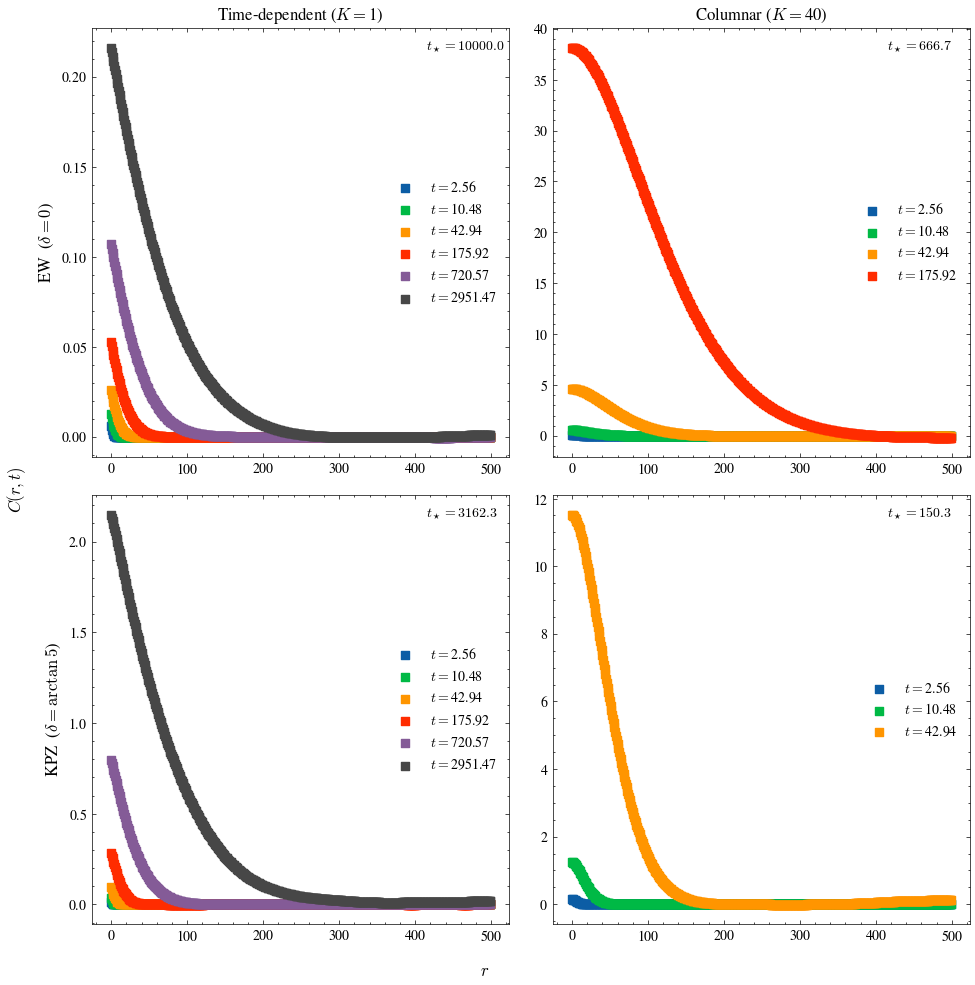

In [21]:
plot_phasecovariance_evolution(avg_df, L, T, tx, Ks=[1,40], save=True)

#### Family-Vicsek collapse

/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_collapse.py:353: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,


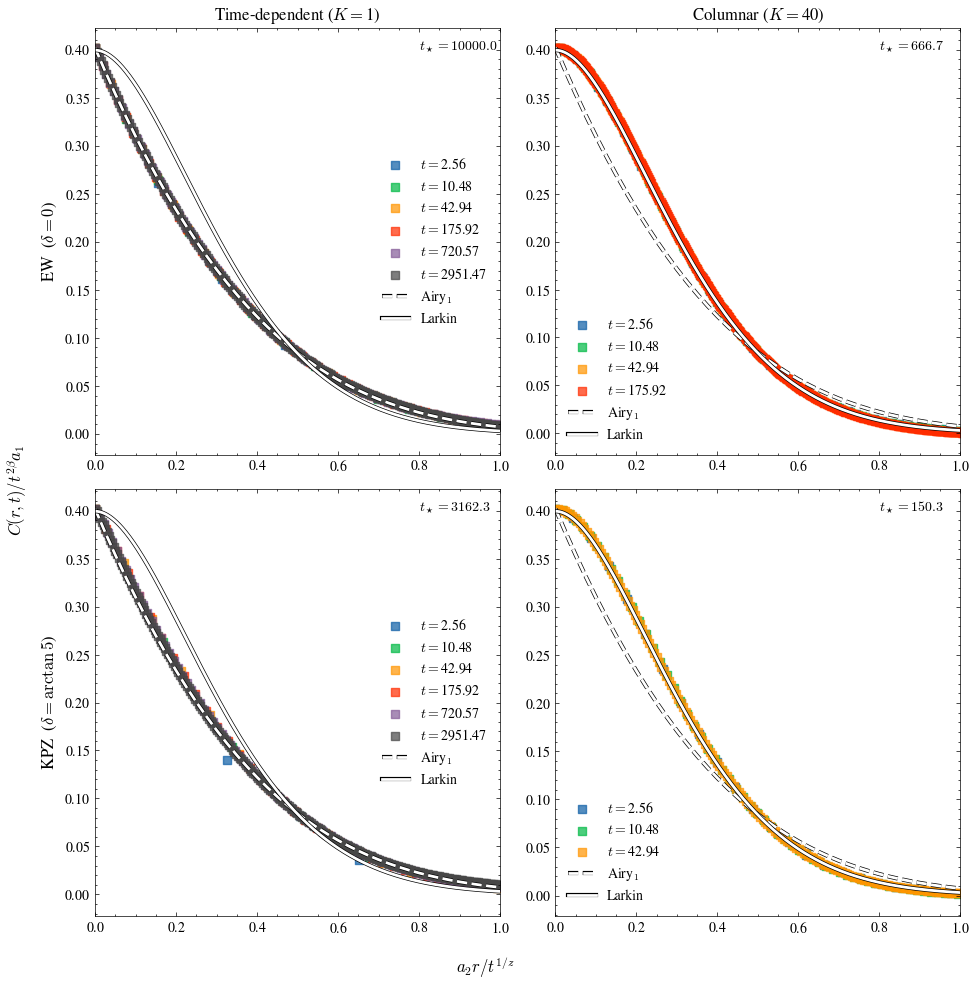

In [22]:
_, _ = plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40])

/tmp/ipykernel_2359369/1978906511.py:66: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,


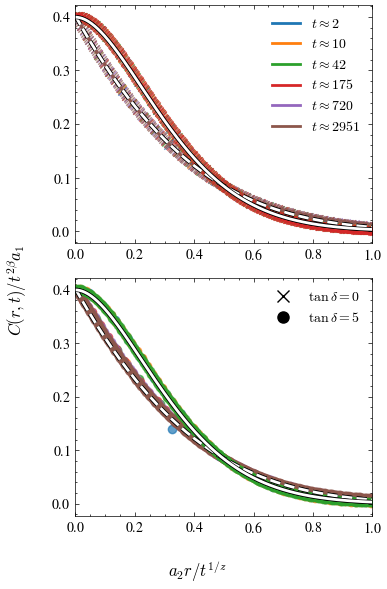

In [23]:

def covariance_constants(tti, C_Phi_t, beta, z, fun, x0=0.5):
    a_1 = C_Phi_t[0] / (tti**(2*beta) * fun[0])
    target = a_1 * tti**(2*beta) * fun[x0]

    # find the FIRST r where C drops below target (C is decreasing initially)
    C = C_Phi_t[:len(C_Phi_t)//2]
    rr = np.arange(C.size)
    
    # If target is above C(0) or below the min, no meaningful crossing in-range
    if target >= C[0] or target <= C.min():
        return np.nan, np.nan
    
    # first index where C <= target
    idx = np.argmax(C <= target)  # returns 0 if never true; guarded by check above
    
    # bracket between idx-1 (above target) and idx (below target)
    i0 = idx - 1
    i1 = idx
    
    C0, C1 = C[i0], C[i1]
    r0, r1 = float(i0), float(i1)
    
    # linear interpolation
    r_intermediate = r0 + (target - C0) * (r1 - r0) / (C1 - C0)

    a_2 = (tti**(1/z)) * x0 / r_intermediate
    return a_1, a_2


with open("../airy_1_values.txt", 'r') as f:
    Airy_1 = {float(line.split(" ")[0]): float(line.split(" ")[1]) for line in f.readlines()}


def larkin_inv_ft(x, eps=1e-6, rtol=1e-10, atol=1e-12, limit=300, sigma=0.102):
    """
    Computes  F^{-1}[ ((1 - e^{-k^2})^2 / k^4) ](x)
    using the convention:
        F^{-1}[g](x) = (1/2π)∫_{-∞}^{∞} e^{ikx} g(k) dk
                     = (1/π) ∫_0^∞ cos(kx) g(k) dk   (g even)

    Parameters
    ----------
    x : float
        Evaluation point.
    eps : float
        Threshold for using the small-k series to avoid 0/0.
    rtol, atol : float
        quad tolerances.
    limit : int
        quad subinterval limit.

    Returns
    -------
    float
        Value of the inverse transform at x.
    """
    x = x/1.35

    def g(kappa):
        ak = abs(kappa)
        if ak < eps:
            k2 = kappa*kappa
            return 1.0 - k2 + (7.0/12.0)*k2*k2  # series at κ=0
        return (1.0 - np.exp(-kappa*kappa))**2 / (kappa**4)

    val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,
                  epsrel=rtol, epsabs=atol, limit=limit)
    return 4*sigma*val  # (1/2π) over R -> (1/π) cosine integral


def plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40], t_intervals=3, nu=40.0, dx=1.0, save=False):

    fig, ax = plt.subplots(2, 1, figsize=(4,6))
    # fig.suptitle("Phase covariance collapse under different noise types, for $L=$" + str(L))

    fig.supxlabel(r"$a_2 r/ t^{1/z}$")
    fig.supylabel(r"$C(r,t)/ t^{2\beta} a_1$")

    a_1_dict = {}
    a_2_dict = {}

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):

        a_1_dict[typenoise] = {}
        a_2_dict[typenoise] = {}

        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            a_1_dict[typenoise][deltaname] = []
            a_2_dict[typenoise][deltaname] = []
            
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["L"] == L)
                & (avg_df["T"] == T)
                & (avg_df["deltaname"] == deltaname)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            )
            sub = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub.iterrows():
                t = row["t"]
                mean_phasecovariance = row["mean_phasecovariance"]
                L = row["L"]
                K = row["K"]

                # Exponents
                z = z_dict[typenoise][delta_to_label[deltaname]]
                alpha = alpha_dict[typenoise][delta_to_label[deltaname]]
                beta = beta_dict[typenoise][delta_to_label[deltaname]]
            
                t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

                for ti in range(len(t))[::t_intervals]:

                    if t[ti] > 0 and t[ti] < t_cross:

                        rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                        rrange = np.array(range(rlen))

                        a_1, a_2 = covariance_constants(t[ti], mean_phasecovariance[ti,:], beta, z, fun=Airy_1) 
                        a_1_dict[typenoise][deltaname].append(a_1)
                        a_2_dict[typenoise][deltaname].append(a_2)

                        # Collapse variables
                        a2rt1z = rrange[:rlen//2] * a_2 / t[ti]**(1/z_dict[typenoise][delta_to_label[deltaname]])
                        Ct2ba1 = mean_phasecovariance[ti,:rlen//2] / (a_1 * t[ti]**(2*beta_dict[typenoise][delta_to_label[deltaname]]))

                        ax[j].scatter(a2rt1z, Ct2ba1, label=f"$t=${np.round(t[ti],2)}",
                                      c=timecolordict[ti], marker=markerdict[j], alpha=0.7)

                # Airy_1 and F^{-1}(Larkin) values 
                ax[j].plot(list(Airy_1.keys()), list(Airy_1.values()),
                             lw=2, color="white", linestyle="--", label=r"Airy$_1$",
                             path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
                ax[j].plot(np.linspace(0, 1, 400), [larkin_inv_ft(rr) for rr in np.linspace(0, 1, 400)],
                             lw=2, color="white", label="Larkin",
                             path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()]) 

    ax[0].set_xlim(0,1)
    ax[1].set_xlim(0,1)

    # ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
    # ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")     
    # ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
    # ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    ax[0].legend(
        handles=time_handles,
        loc="best"
    )
    
    ax[1].legend(
        handles=delta_handles,
        loc="best"
    )
    
    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/TFM/phasecovariance_collapse_{L}.png", dpi=300)
    plt.show()

    return a_1_dict, a_2_dict

_, _ = plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40], save=True)

### 6. Phase fluctuations statistics

Skewness (TimeDep, 0): -0.0023385592717585575
Skewness (TimeDep, atan5): 0.33324433376476786
Skewness (Columnar, 0): 0.01438771764792263
Skewness (Columnar, atan5): 0.13200855578465423


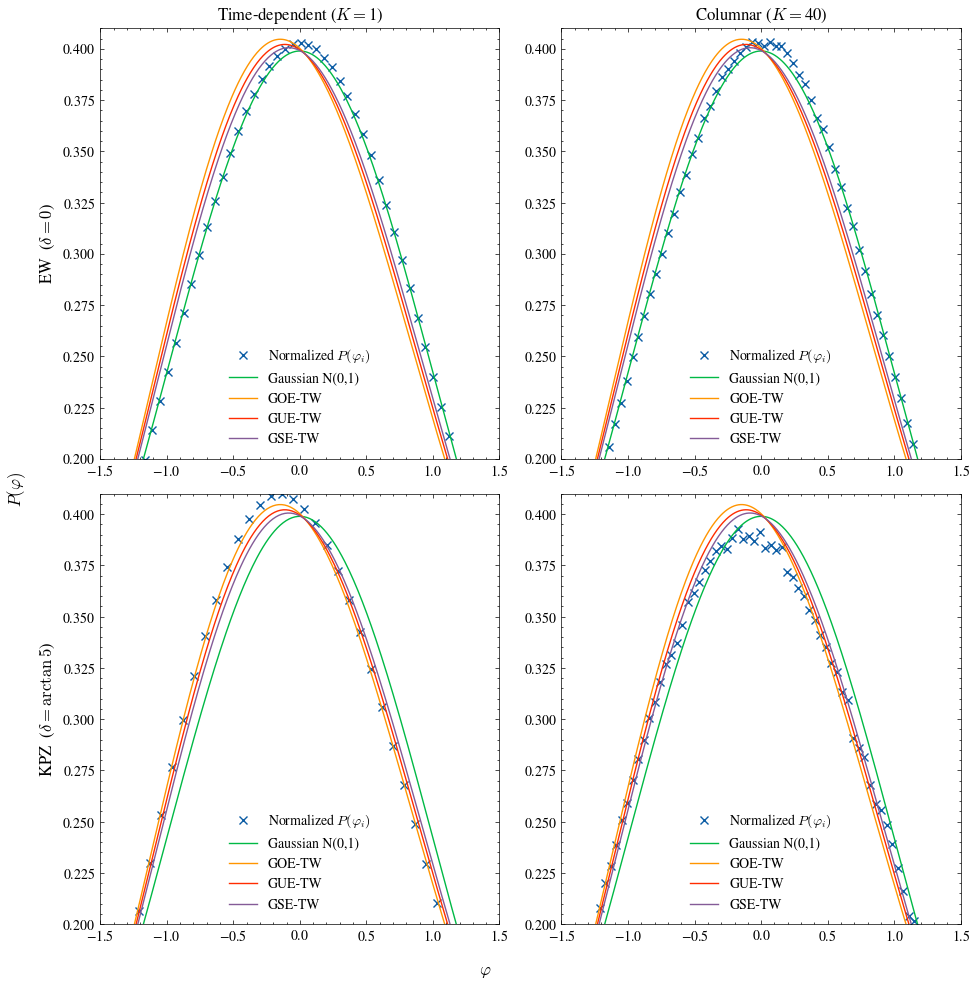

In [24]:
plot_fluctuations_pdf(avg_df, L, T, tx, Ks=[1,40], save=True)

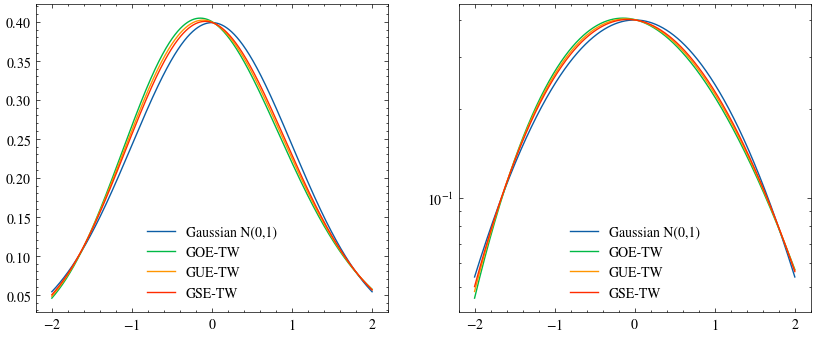

In [32]:
## Loading TW pre-saved data
from scipy.interpolate import interp1d

data = np.loadtxt('../tw_data.csv', delimiter=',', skiprows=1)
s_vals = data[:, 0]
ds = s_vals[1] - s_vals[0]
tw_interp = {}

# Create interpolators for each TW distribution
for col, beta in enumerate([1, 2, 4], start=1):
    pdf = data[:, col]
    # Calculate moments from CSV to standardize
    mu = np.sum(s_vals * pdf) * ds
    sigma = np.sqrt(np.sum(s_vals**2 * pdf) * ds - mu**2)
    # Map to standardized coordinates
    tw_interp[beta] = interp1d((s_vals - mu) / sigma, pdf * sigma, 
                               kind='cubic', bounds_error=False, fill_value=0.0)


def normalized_tw_pdf(x, beta, grid_min=-200.0, grid_max=100.0, n_grid=20000000):
    """
    Standardized Tracy–Widom PDF (mean 0, variance 1) for beta=1,2,4.

    Returns f_std(x) where if Y ~ TW_beta, then X = (Y - mu)/sigma has PDF:
        f_std(x) = sigma * f_Y(sigma*x + mu)
    """
    TW = TracyWidom(beta=beta)

    # Build pdf function
    pdf_fn = lambda y: TW.pdf(y)

    mu, sigma = _estimate_moments_from_pdf(
        pdf_fn, grid_min=grid_min, grid_max=grid_max, n=n_grid
    )
    return TW.pdf(sigma * x + mu) * sigma


fig, ax = plt.subplots(1,2,figsize=(10,4))

# Gaussian N(0,1)
xx = np.linspace(-2, 2, 1500)
gauss_pdf = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * xx**2)
ax[0].plot(xx, gauss_pdf, label='Gaussian N(0,1)')
ax[1].plot(xx, gauss_pdf, label='Gaussian N(0,1)')

# Tracy–Widom PDFs
ax[0].plot(xx, tw_interp[1](xx), label='GOE-TW')
ax[0].plot(xx, tw_interp[2](xx), label='GUE-TW')
ax[0].plot(xx, tw_interp[4](xx), label='GSE-TW')
ax[1].plot(xx, tw_interp[1](xx), label='GOE-TW')
ax[1].plot(xx, tw_interp[2](xx), label='GUE-TW')
ax[1].plot(xx, tw_interp[4](xx), label='GSE-TW')

ax[0].legend()
ax[1].legend()

# ax[0].set_xlim(-1.5,1.5)
# ax[0].set_ylim(0.2,0.41)
# ax[1].set_xlim(-1.5,1.5)
# ax[1].set_ylim(0.15,0.41)

ax[1].set_yscale("log")

plt.show()

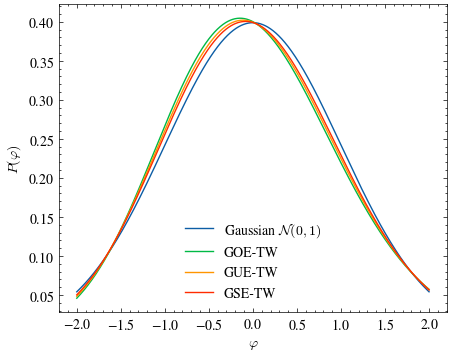

In [37]:
## Loading TW pre-saved data
from scipy.interpolate import interp1d

data = np.loadtxt('../tw_data.csv', delimiter=',', skiprows=1)
s_vals = data[:, 0]
ds = s_vals[1] - s_vals[0]
tw_interp = {}

# Create interpolators for each TW distribution
for col, beta in enumerate([1, 2, 4], start=1):
    pdf = data[:, col]
    # Calculate moments from CSV to standardize
    mu = np.sum(s_vals * pdf) * ds
    sigma = np.sqrt(np.sum(s_vals**2 * pdf) * ds - mu**2)
    # Map to standardized coordinates
    tw_interp[beta] = interp1d((s_vals - mu) / sigma, pdf * sigma, 
                               kind='cubic', bounds_error=False, fill_value=0.0)


def normalized_tw_pdf(x, beta, grid_min=-200.0, grid_max=100.0, n_grid=20000000):
    """
    Standardized Tracy–Widom PDF (mean 0, variance 1) for beta=1,2,4.

    Returns f_std(x) where if Y ~ TW_beta, then X = (Y - mu)/sigma has PDF:
        f_std(x) = sigma * f_Y(sigma*x + mu)
    """
    TW = TracyWidom(beta=beta)

    # Build pdf function
    pdf_fn = lambda y: TW.pdf(y)

    mu, sigma = _estimate_moments_from_pdf(
        pdf_fn, grid_min=grid_min, grid_max=grid_max, n=n_grid
    )
    return TW.pdf(sigma * x + mu) * sigma


fig, ax = plt.subplots(1,1,figsize=(5,4))

# Gaussian N(0,1)
xx = np.linspace(-2, 2, 1500)
gauss_pdf = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * xx**2)
ax.plot(xx, gauss_pdf, label=r'Gaussian $\mathcal{N}(0,1)$')

# Tracy–Widom PDFs
ax.plot(xx, tw_interp[1](xx), label='GOE-TW')
ax.plot(xx, tw_interp[2](xx), label='GUE-TW')
ax.plot(xx, tw_interp[4](xx), label='GSE-TW')

ax.legend()
ax.set_xlabel(r"$\varphi$")
ax.set_ylabel(r"$P(\varphi)$")

plt.savefig("Figures/TFM/PDFs.png", dpi=300)
plt.show()